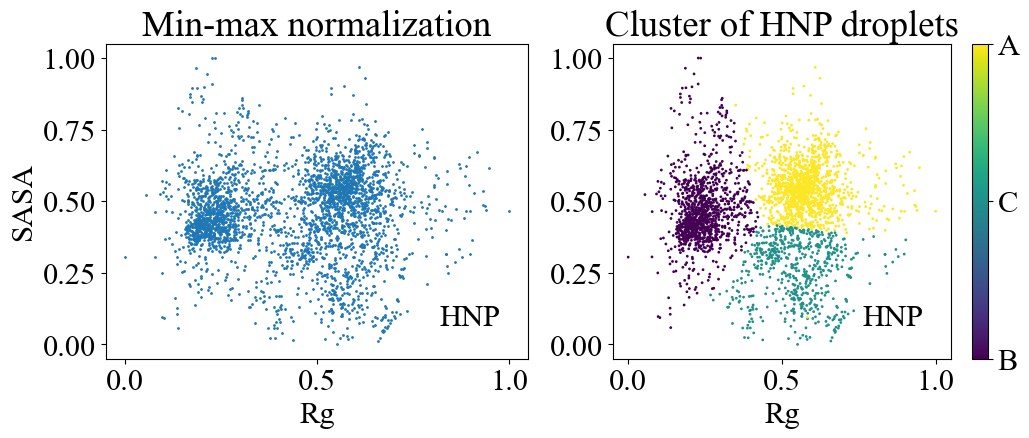

In [ ]:
##max-min normalization
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
import numpy as np

X = [] #x==Rg, y==SASA
t=[]

nox = []
noy = []
with open("sasa-rg.xvg",'r') as file:
    content=file.readlines()
    for index,lin in enumerate(content):
        t.append(index+1)
        X.append([eval(lin.split()[2]),eval(lin.split()[1])])
        nox.append(eval(lin.split()[2]))
        noy.append(eval(lin.split()[1]))

noxx = [0 for i in range(len(nox))]
noyy = [0 for i in range(len(nox))]
for index,val in enumerate(nox):
    noxx[index] = (val-min(nox))/(max(nox)-min(nox))

for index,val in enumerate(noy):
    noyy[index] = (val-min(noy))/(max(noy)-min(noy))
 
XX = []
for i in range(len(noxx)):
    XX.append([noxx[i],noyy[i]])

kmeans = KMeans(n_clusters=3, random_state=23)

kmeans.fit(XX)
centers = kmeans.cluster_centers_
labels = kmeans.labels_

#sns.set(font_scale=1.2)
plt.rc('font',family=['Times New Roman', 'SimSun'], size=22)

plt.figure(figsize=(12, 9))
plt.subplot(2,2,1)
plt.scatter(noxx,noyy,s=1,cmap='RdBu',label='HNP')
plt.xlabel('Rg')
plt.ylabel('SASA')
plt.title('Min-max normalization')
plt.legend(loc='lower right',frameon=False)


plt.subplot(2,2,2)
scatter = plt.scatter(np.array(XX)[:,0],np.array(XX)[:,1],c=labels, s=1, cmap='viridis', alpha=1,label='HNP')
groups=['B','C','A']
plt.colorbar(scatter,ticks=range(0, 3)).set_ticklabels(groups)
plt.xlabel('Rg')
plt.title('Cluster of HNP droplets')
plt.legend(loc='lower right',frameon=False)
plt.show()



[2 2 2 ... 0 0 0]
[[0], [0], [0], [0]]
[0.3875374875041653, 0.20026657780739754, 0.4121959346884372, 0.0]


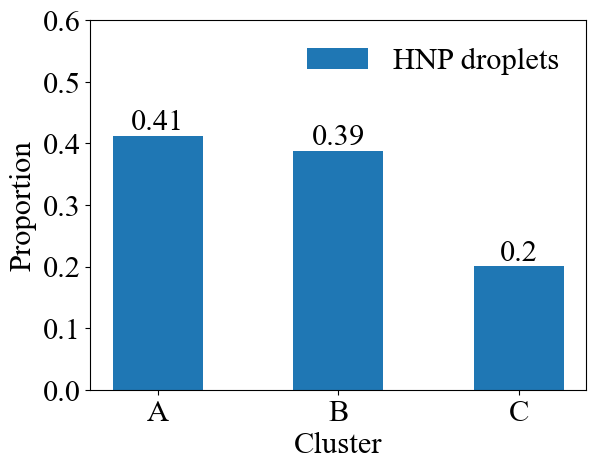

In [2]:
import matplotlib.pyplot as plt
print(labels)

pct = [[0] for i in range(4)]
print(pct)

for index,line in enumerate(labels):
    pct[line][0]+=1

pcl = [x[0]/len(labels) for x in pct]
print(pcl)

x = ['B','C','A']#,'A']#,'4','5','6','7']
y = pcl

lis=dict(zip(x,y))
lis_sorted = dict(sorted(lis.items(), key=lambda item: item[1], reverse=True))

xx = []
yy = []

for label,val in lis_sorted.items():
    xx.append(label)
    yy.append(val)

width = 0.5
plt.bar(xx, yy,width=width,label='HNP droplets')#,color=colors)

for value, label in zip(yy, xx):
    plt.text(label, value, str(round(value, 2)), ha='center', va='bottom')

plt.ylim(0,0.6)
plt.xlabel('Cluster')
plt.ylabel('Proportion')
plt.legend(loc='upper right',frameon=False)
plt.show()

In [3]:
import math
with open('minmax.xvg','w') as file:
    indexlis = []
    for i in range(len(noxx)):
        file.write("{}  {}  {}\n".format(i+1,noxx[i],noyy[i]))
        indexlis.append(i+1) 

centermax = centers[2]
distancelis = [np.linalg.norm(np.array(point) - np.array(centermax)) for point in XX]
dic = dict(zip(indexlis,distancelis))

dic_sorted = dict(sorted(dic.items(), key=lambda item: item[1], reverse=False))

print(centers)
print(dic_sorted)

[[0.2427808  0.46635408]
 [0.54971443 0.25923454]
 [0.58254833 0.55240377]]
{1177: 0.0019250013188170365, 1489: 0.0030183054021212154, 1122: 0.004744175491759264, 1573: 0.004782388232298819, 1106: 0.005407771064096184, 1182: 0.0061176013424127295, 1678: 0.006383058324616826, 1214: 0.006535189237363187, 1144: 0.006723633771077524, 1487: 0.007314183097751928, 1095: 0.007391755971396117, 1348: 0.007407233982230068, 1205: 0.007768481312406922, 1885: 0.008455948356621909, 1408: 0.008479521748946844, 1304: 0.008796101141826496, 1273: 0.008833460508087603, 1939: 0.010053944633927614, 1794: 0.010087538235498787, 1174: 0.01018611498320553, 1358: 0.010188728224699406, 1212: 0.010668355428641023, 1807: 0.010795388434203785, 1164: 0.010824600368393604, 1491: 0.011971242147829094, 1490: 0.012310788817289711, 1374: 0.012429266567309045, 1133: 0.012760055050552114, 1192: 0.013251279647926118, 1511: 0.013315921271908629, 1432: 0.01337145062528418, 1121: 0.013546303537932255, 1137: 0.014165480790537163

No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.


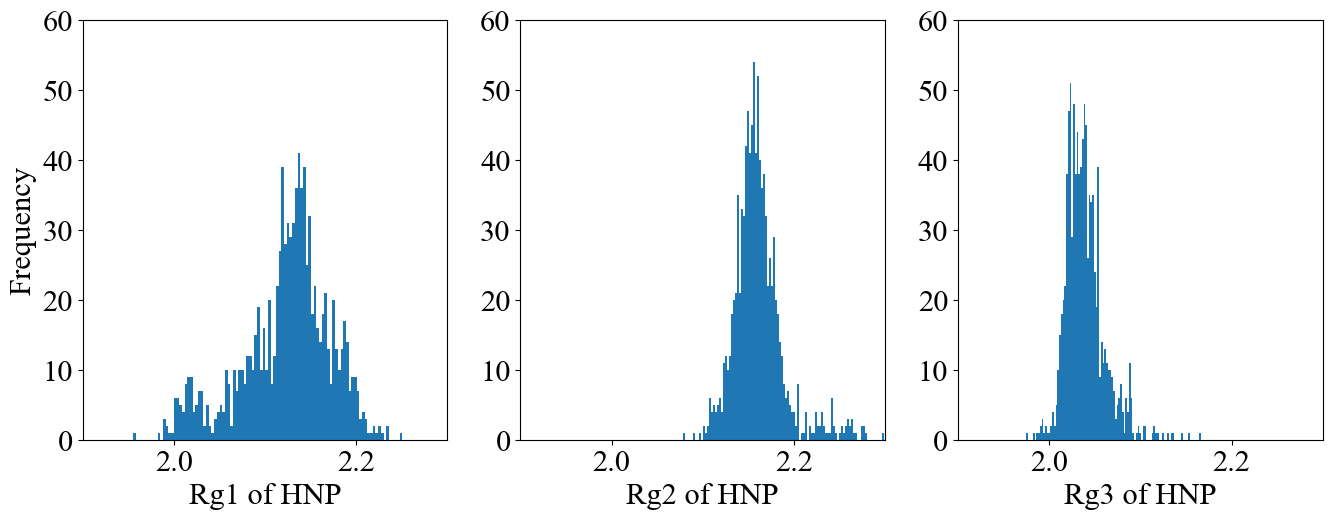

In [ ]:
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
import numpy as np

plt.rc('font',family=['Times New Roman', 'SimSun'], size=22)

X = [] #x==Rg, y==SASA

Rg1 = []
Rg2 = []
Rg3 = []
with open("sasa-rg.xvg",'r') as file:
    content=file.readlines()
    for index,lin in enumerate(content):
        if index <= 999:
            Rg1.append(eval(lin.split()[2]))
        if index > 999 and index<=1999:
            Rg2.append(eval(lin.split()[2]))
        if index > 1999:
            Rg3.append(eval(lin.split()[2]))
    
plt.figure(figsize=(16, 12))
plt.subplot(2,3,1)
plt.ylim(0,60)
plt.xlim(1.9,2.3)
plt.hist(Rg1,bins=100)#,label='Trajectory 1 of F5A')
plt.xlabel('Rg1 of HNP')
plt.ylabel('Frequency')
plt.legend(loc='upper right',frameon=False)

plt.subplot(2,3,2)
plt.ylim(0,60)
plt.xlim(1.9,2.3)
plt.hist(Rg2,bins=100)#,label='Trajectory 2 of F5A')
plt.xlabel('Rg2 of HNP')
plt.legend(loc='upper right',frameon=False)

plt.subplot(2,3,3)
plt.ylim(0,60)
plt.xlim(1.9,2.3)
plt.hist(Rg3,bins=100)#,label='Trajectory 3 of F5A')
plt.xlabel('Rg3 of HNP')
plt.legend(loc='upper right',frameon=False)

plt.show()

No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.


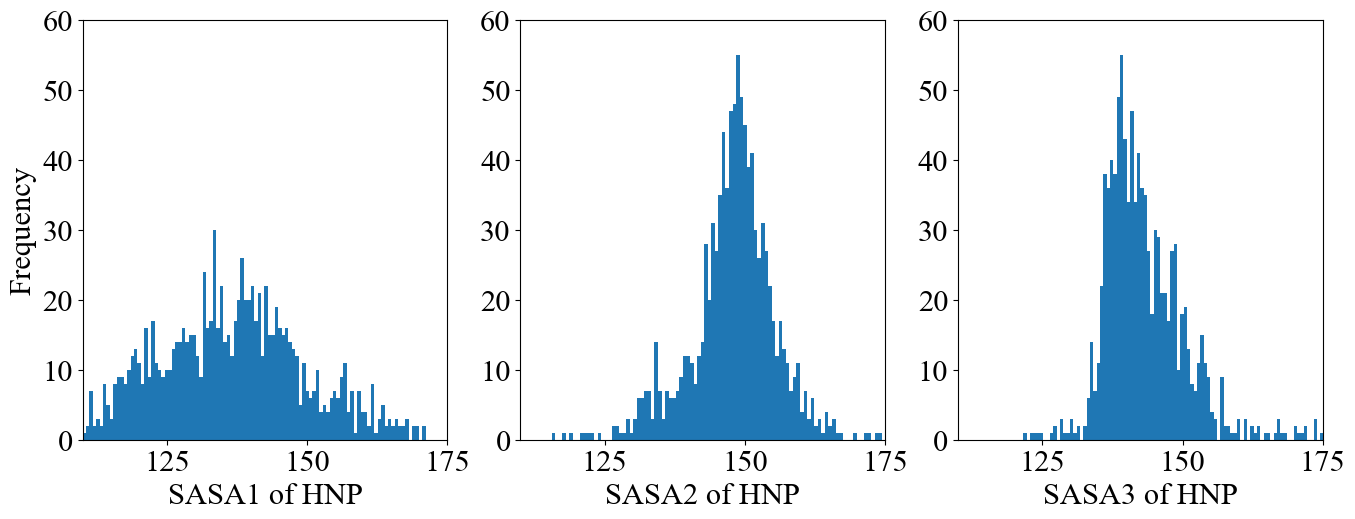

In [7]:
X = [] #x==Rg, y==SASA

SASA1 = []
SASA2 = []
SASA3 = []
with open("sasa-rg.xvg",'r') as file:
    content=file.readlines()
    for index,lin in enumerate(content):
        if index <= 999:
            SASA1.append(eval(lin.split()[1]))
        if index > 999 and index<=1999:
            SASA2.append(eval(lin.split()[1]))
        if index > 1999:
            SASA3.append(eval(lin.split()[1]))
    
plt.figure(figsize=(16, 12))
plt.subplot(2,3,1)
plt.ylim(0,60)
plt.xlim(110,175)
plt.hist(SASA1,bins=100)#,label='Trajectory 1 of F5A')
plt.xlabel('SASA1 of HNP')
plt.ylabel('Frequency')
plt.legend(loc='upper right',frameon=False)

plt.subplot(2,3,2)
plt.ylim(0,60)
plt.xlim(110,175)
plt.hist(SASA2,bins=100)#,label='Trajectory 2 of F5A')
plt.xlabel('SASA2 of HNP')
plt.legend(loc='upper right',frameon=False)

plt.subplot(2,3,3)
plt.ylim(0,60)
plt.xlim(110,175)
plt.hist(SASA3,bins=100)#,label='Trajectory 3 of F5A')
plt.xlabel('SASA3 of HNP')
plt.legend(loc='upper right',frameon=False)

plt.show()


In [10]:
## 将tDNAd真实结构的CG加入到聚类图里